# ScamSense- Multilingual Scam Detection & Explanation System
**A multilingual (English, Singlish, Malay, Tamil, Mandarin) system that detects scam messages, explains the reasoning, scores the risk, and delivers it via API + Telegram bot.**

---

## Pipeline Overview

| Step | Process | Goal |
|---|---|---|
| 1 | Synthetic Data Generation | Create scam examples in 5 languages |
| 2 | Data Cleaning & Splitting | Build a clean, balanced, leak-free dataset |
| 3 | Model Training & Comparison | Find the best scam classifier |
| 4 | Agentic Reasoning | Explain + risk-score each prediction |
| 5 | Deployment | Serve it live via API + Telegram |


## Step 1 — Synthetic Data Generation

| | |
|---|---|
| **Input** | 63 English scam templates + 150 Singlish templates, 12 scam categories, 17 slot dimensions |
| **Process** | Fill slots → oversample → dedup → translate (EN→MS/TA/ZH via NLLB-200) |
| **Output** | `synthetic_dataset.csv` — 24,383 scam messages |

| Language | EN | Singlish | ZH | MS | TA |
|---|---|---|---|---|---|
| Count | 5,000 | 5,000 | 4,964 | 4,781 | 4,638 |


## Step 2 — Data Cleaning & Splitting

| | |
|---|---|
| **Input** | 24,383 synthetic scam rows + real ham data (emails, SMS, job postings) = 232,616 raw rows |
| **Process** | Remove duplicates/junk → balance ham per language → stratified split → normalize |
| **Output** | 136,930 clean rows, exact 50/50 scam/ham, zero overlap across splits |

| Split | Rows | Balance |
|---|---|---|
| Train | 95,851 | 50/50 |
| Validation | 20,539 | 50/50 |
| Test | 20,540 | 50/50 |

## Step 3 — Model Training & Comparison

| | |
|---|---|
| **Input** | Train/Val/Test splits, 6 model configs (XLM-R variants + mBERT baseline) |
| **Process** | Train each → pick best by validation F1 → confirm on test set |
| **Output** | Final model: **XLM-RoBERTa**, saved + pushed to Hugging Face Hub |

| Model | Test F1 | AUC |
|---|---|---|
| XLM-R (lr=2e-5, batch=16) | 0.9917 | 0.9982 |
| **XLM-R (lr=2e-5, batch=32) — Winner** | **0.9929** | **0.9990** |
| XLM-R (lr=3e-5, batch=32) | 0.9912 | 0.9978 |
| + Weighted Sampler | 0.9925 | 0.9983 |
| + Text Normalization | 0.9858 | 0.9980 |
| mBERT (frozen baseline) | 0.9282 | 0.9804 |

**Per-language:** MS/ZH near 100% F1 · English hardest (weakest despite being 72% of data)


## Step 4 — Agentic Reasoning (Explain + Risk Score)

| | |
|---|---|
| **Input** | Trained classifier + SPF scam taxonomy (12 categories) + SPF awareness corpus |
| **Process** | Detect → explain (SHAP + retrieval) → classify scam type → compute risk score |
| **Output** | Full risk report per message: type, tier, score |

**Scoring rule:** `adjusted score = base score × scam probability` → Tier: Critical ≥85 / High ≥65 / Medium ≥40 / Low <40

| Language | Scam Type | Confidence | Tier | Score |
|---|---|---|---|---|
| English | Phishing | 100.0% | High | 77 |
| Tamil | Investment | 100.0% | Critical | 95 |
| Malay | Job Scam | 100.0% | High | 80 |
| Singlish | Fake Friend | 99.7% | Medium | 61 |
| Mandarin | Govt. Impersonation | 99.6% | Critical | 92 |
| All 5 Ham cases | — | 99.8–100% | None | 0 |


## Step 5 — Deployment (API + Telegram Bot)

| | |
|---|---|
| **Input** | Same reasoning pipeline as Step 4 (shared module — no separate logic) |
| **Process** | Wrap in FastAPI → log to Supabase → run Telegram bot in parallel |
| **Output** | Live `/predict` endpoint + working Telegram bot ("ScamSense Scout") |

| Endpoint | Purpose |
|---|---|
| `/health` | Service status |
| `/predict` | Run detection on a message |
| `/stats` | Cumulative prediction stats |
| `/history` | Past logged predictions |

**Live stats since deployment:** 69 predictions logged (55 scam / 14 ham, 79.7% scam rate)


## Key Numbers Summary

| Metric | Value |
|---|---|
| Final Model | XLM-RoBERTa |
| Test F1 | 0.9929 |
| Test AUC | 0.9990 |
| Languages | 5 |
| Scam Categories | 12 |
| Final Dataset Size | 136,930 |

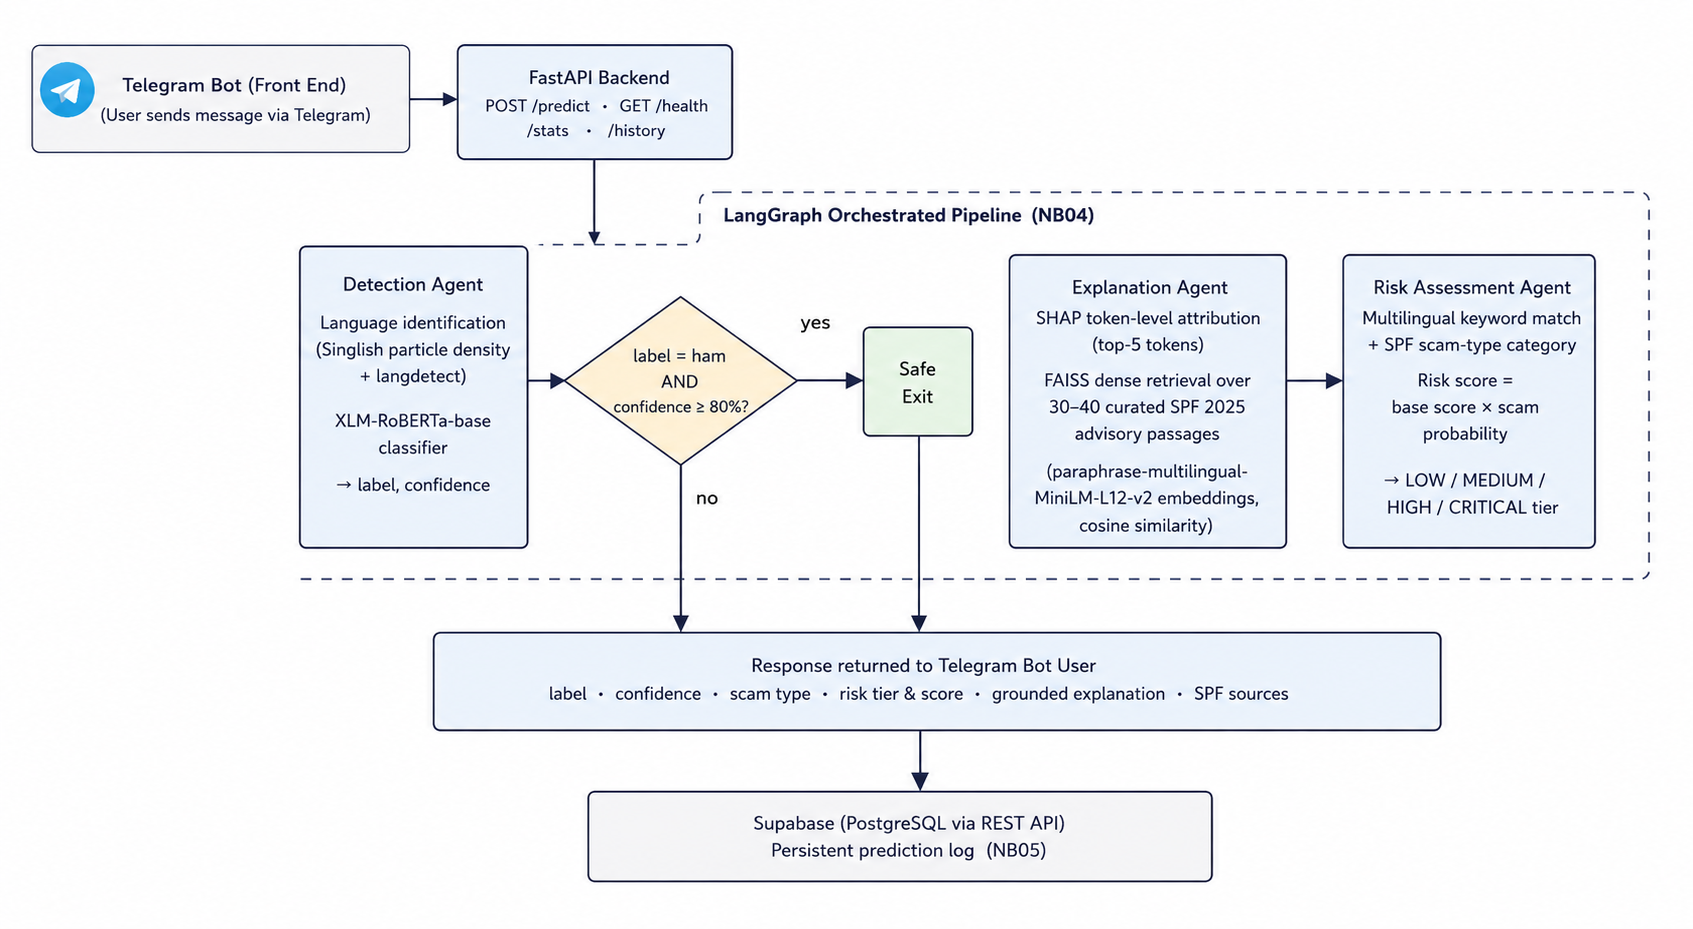
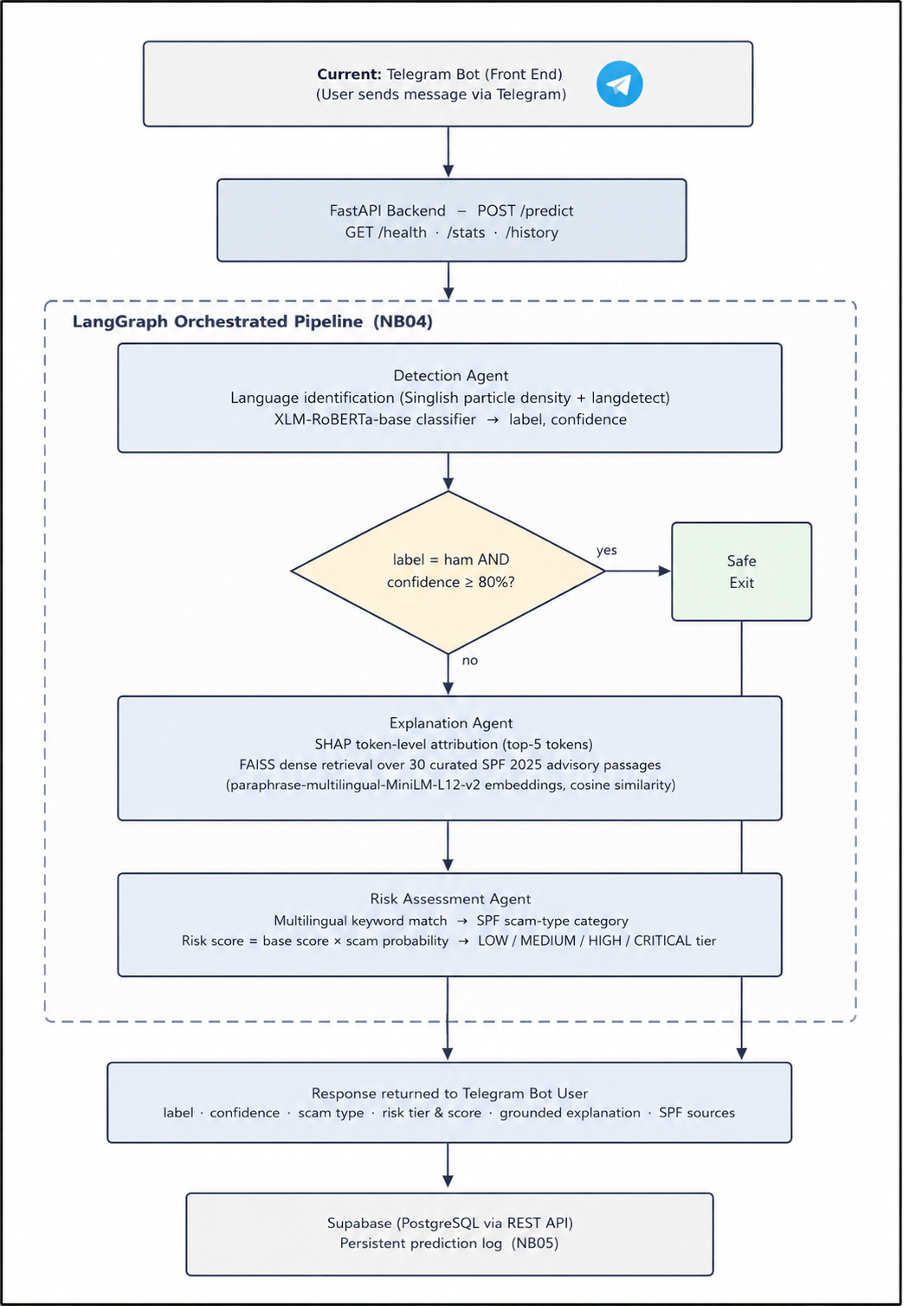

# 01 - Synthetic Data Generation

Generates synthetic scam messages across 5 languages (English, Singlish, Malay, Tamil, Mandarin)
using slot-filled templates and NLLB-200 machine translation.

**Output:** `/kaggle/working/data/synthetic_dataset.csv`

| Step | Description |
|---|---|
| 1 | Setup & paths |
| 2 | Install dependencies |
| 3 | Imports |
| 4 | Slot values & templates |
| 5 | Generate English & Singlish (sanity check) |
| 6 | Generate full English & Singlish datasets |
| 7 | Load NLLB-200 & translate to MS / TA / ZH |
| 8 | Merge, dedup, and save |


## 1. Setup

Define the base paths and create the output folders.


In [1]:
import os  # standard library for working with file paths

# base working directory (Kaggle's writable folder)
BASE_DIR  = "/kaggle/working"
DATA_DIR  = os.path.join(BASE_DIR, "data")      # folder for generated datasets
MODEL_DIR = os.path.join(BASE_DIR, "models")    # folder for saved models
REPORT_DIR = os.path.join(BASE_DIR, "reports")  # folder for reports

# create each folder if it doesn't already exist
for d in [DATA_DIR, MODEL_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print("BASE_DIR:", BASE_DIR)


BASE_DIR: /kaggle/working


## 2. Install Dependencies

Install the libraries needed for translation (Transformers, SentencePiece, PyTorch)
and for progress bars (tqdm).


In [2]:
# install translation dependencies (Transformers, SentencePiece tokenizer, PyTorch, tqdm)
!pip install -q transformers sentencepiece torch tqdm


## 3. Imports

Import the libraries used throughout the notebook and configure warnings/logging.


In [3]:
import random                                          # random sampling of templates/slots
import pandas as pd                                    # building and saving the dataset as a DataFrame
import torch                                           # running the translation model
from tqdm.auto import tqdm                             # progress bars during translation
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, logging as hf_logging  # translation model + tokenizer
import warnings
import os

warnings.filterwarnings("ignore")               # suppress general Python warnings
hf_logging.set_verbosity_error()                 # only show Hugging Face errors, not info/warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # avoid tokenizer multiprocessing warnings
os.environ["TQDM_DISABLE"] = "0"                 # keep tqdm progress bars enabled
os.environ["TQDM_NOTEBOOK"] = "false"            # use plain tqdm bars instead of notebook widgets

random.seed(42)   # fix the random seed so template/slot sampling is reproducible
print("imports done")


imports done


## 4. Slot Values & Templates

Define the vocabulary used to fill in template placeholders (`SLOTS`), the English scam
message templates (`TEMPLATES`), the Singlish templates (`SINGLISH_TEMPLATES`), and the
NLLB-200 language codes (`LANG_MAP`).


In [4]:
# SLOTS: vocabulary used to fill in "{slot_name}" placeholders in the templates below.
# Each key is a slot name; each value is a list of options randomly sampled from.
SLOTS = {
    "bank": [
        "DBS",
        "POSB",
        "OCBC",
        "UOB",
        "Standard Chartered",
        "Citibank",
        "HSBC",
        "Maybank",
        "Trust Bank"
    ],

    "payment_service": [
        "PayNow",
        "FAST",
        "GIRO"
    ],

    "government_service": [
    "Singpass",
    "CPF",
    "myTax Portal",
    "HDB Portal",
    "OneMotoring",
    "HealthHub"
    ],

    "amount": [
        "20",
        "50",
        "100",
        "150",
        "200",
        "250",
        "300",
        "500",
        "750",
        "1000",
        "1500",
        "2000",
        "3000",
        "5000",
        "10000",
        "20000"
    ],

    "frequency": [
        "daily",
        "weekly",
        "monthly",
        "hourly",
        "per session",
        "per hour",
        "per task",
        "per shift",
        "every day",
        "every week"
    ],

    "action": [
        "suspended",
        "locked",
        "frozen",
        "blocked",
        "flagged",
        "restricted",
        "deactivated",
        "disabled",
        "temporarily disabled",
        "placed on hold",
        "under review",
        "under investigation",
        "pending verification",
        "cancelled"
    ],

    "activity": [
        "login",
        "sign-in",
        "transaction",
        "transfer",
        "withdrawal",
        "payment",
        "fund movement",
        "access attempt",
        "OTP verification",
        "identity verification",
        "account login"
    ],

    "service": [
        "online banking",
        "internet banking",
        "mobile app",
        "account access",
        "PayNow access",
        "bank account",
        "savings account",
        "debit card",
        "credit card",
        "ATM card",
        "card services",
        "e-wallet"
    ],

    "urgency": [
        "Act now",
        "Immediate action required",
        "Verify immediately",
        "Verify your identity now",
        "Security alert",
        "Immediate verification required",
        "Do not ignore this message",
        "Click the link to resolve",
        "Contact support immediately",
        "Your account is at risk",
        "Failure to act will result in permanent closure",
        "Your access will be revoked",
        "Your account will be terminated",
        "Confirm your details to avoid disruption",
        "Reply now to avoid penalty",
        "Respond within 24 hours",
        "Respond before midnight",
        "This is your final notice",
        "Failure to respond will result in legal action"
    ],

    "role": [
        "data entry clerk",
        "social media assistant",
        "survey taker",
        "online reviewer",
        "product tester",
        "content moderator",
        "listing assistant",
        "order processor",
        "part-time assistant",
        "remote assistant",
        "customer service agent",
        "data annotator",
        "app reviewer",
        "shopping assistant"
    ],

    "platform": [
        "Telegram",
        "WhatsApp",
        "Signal",
        "WeChat",
        "Line",
        "Facebook",
        "Instagram",
        "TikTok",
        "Discord"
    ],

    "penalty": [
        "SGD {fine} fine",
        "legal action",
        "court summons",
        "account termination",
        "bank account suspension",
        "loss of account access",
        "service disruption",
        "credit score impact",
        "blacklisting",
        "additional charges"
    ],

    "area": [
        "Jurong",
        "Tampines",
        "Woodlands",
        "Punggol",
        "Clementi",
        "Bishan",
        "Bedok",
        "Toa Payoh",
        "Ang Mo Kio",
        "Sengkang",
        "Hougang",
        "Yishun",
        "Bukit Batok",
        "Pasir Ris",
        "Serangoon"
    ],

    "fine": [
        "100",
        "200",
        "500",
        "1000",
        "2000",
        "5000"
    ],

    "organization": [
    "Singapore Police Force",
    "Immigration & Checkpoints Authority",
    "Monetary Authority of Singapore",
    "Ministry of Manpower",
    "Ministry of Health",
    "Inland Revenue Authority of Singapore",
    "CPF Board",
    "GovTech",
    "Housing & Development Board",
    "Land Transport Authority"
    ],

    "delivery_company": [
        "SingPost",
        "Ninja Van",
        "J&T Express",
        "DHL",
        "FedEx"
    ],

    "currency": [
        "SGD",
        "S$"
    ]
}

# TEMPLATES: English scam message templates, grouped by scam type.
# 12 scam types x 5-6 templates each = 63 base English strings.
# Scam type taxonomy is based on the SPF Annual Scams and Cybercrime Brief 2025.
TEMPLATES = {
    "phishing": [
        "Your {bank} account has been {action}. {urgency}.",
        "Suspicious {activity} detected on your {bank} account. {urgency}.",
        "Your {bank} {service} is blocked. Verify identity to restore. {urgency}.",
        "Urgent security alert from {bank}. Confirm your details now. {urgency}.",
        "Unauthorised {activity} on your {bank} account. {urgency}.",
        "Your {payment_service} transaction has been {action}. {urgency}.",
    ],
    "job_scam": [
        "Earn {currency} {amount} {frequency} working from home. {urgency}.",
        "Online job available. {currency} {amount} {frequency} payout guaranteed. {urgency}.",
        "{platform} task job. Commission of {currency} {amount} {frequency}. {urgency}.",
        "Part-time {role} needed urgently. Earn {currency} {amount} {frequency}. {urgency}.",
        "No experience needed. {role} earns {currency} {amount} daily. {urgency}.",
    ],
    "investment": [
        "Invest {currency} {amount} and double your money in 30 days. {urgency}.",
        "Crypto scheme guarantees {currency} {amount} returns weekly. {urgency}.",
        "Start with {currency} {amount} and earn passive income {frequency}. {urgency}.",
        "Exclusive investment group. {currency} {amount} entry. Guaranteed returns. {urgency}.",
        "Limited slots for high-yield fund. Minimum investment {currency} {amount}. {urgency}.",
    ],
    "ecommerce": [
        "Cheap deal available. Pay {currency} {amount} now to secure the item. {urgency}.",
        "Limited stock sale. Transfer {currency} {amount} immediately. {urgency}.",
        "Order confirmed. Pay {currency} {amount} deposit to release your goods. {urgency}.",
        "Flash sale ends tonight. Pay {currency} {amount} to lock in the price. {urgency}.",
        "Seller requires a {currency} {amount} deposit before shipping. {urgency}.",
    ],
    "bank_impersonation": [
        "Your {bank} account will be frozen unless you verify. {urgency}.",
        "Suspicious {activity} detected in your {bank} account. {urgency}.",
        "{bank} security team detected unauthorised access. {urgency}.",
        "Your {bank} {service} requires re-verification. {urgency}.",
        "{bank} alert: new device login attempt blocked. Confirm identity. {urgency}.",
        "Suspicious {activity} via {payment_service} detected on your {bank} account. {urgency}.",
    ],
    "government_impersonation": [
        "Official notice from {organization}. {urgency}.",
        "{organization} requires you to verify your identity immediately. {urgency}.",
        "{organization} has detected an issue with your records. {urgency}.",
        "{organization} requires immediate action to avoid {penalty}. {urgency}.",
        "Your records with {organization} require verification. {urgency}.",
    ],
    "fake_friend": [
        "Hi, changed number. This is me. Transfer {currency} {amount} urgently. {urgency}.",
        "Lost my phone. Please send {currency} {amount} to this new number. {urgency}.",
        "It's me, in trouble. Need {currency} {amount} now. Will repay tomorrow. {urgency}.",
        "New number. Family emergency. Transfer {currency} {amount} via {platform}. {urgency}.",
        "Hi Mum, it's me. Stuck overseas. Send {currency} {amount} please. {urgency}.",
        "New number. Please transfer {currency} {amount} via {payment_service} urgently. {urgency}.",
    ],
    "parcel_delivery": [
        "Your {delivery_company} parcel cannot be delivered. Pay {currency} {amount} to reschedule. {urgency}.",
        "{delivery_company} delivery failed. Pay {currency} {amount} to release your parcel. {urgency}.",
        "Your package with {delivery_company} is held at customs. {currency} {amount} clearance fee required. {urgency}.",
        "{delivery_company} attempted delivery but your parcel is on hold. Pay {currency} {amount}. {urgency}.",
        "Update your delivery details for your {delivery_company} parcel and pay {currency} {amount}. {urgency}.",
    ],
    "rental": [
        "Room available in SG. Pay {currency} {amount} deposit immediately. {urgency}.",
        "Cheap rental. Transfer {currency} {amount} booking fee now to reserve. {urgency}.",
        "HDB room for rent. Pay {currency} {amount} to hold unit. {urgency}.",
        "Landlord requires {currency} {amount} deposit via {platform}. {urgency}.",
        "Last unit at this price. Reserve with {currency} {amount} now. {urgency}.",
    ],
    "loan": [
        "Fast loan of {currency} {amount} approved instantly. {urgency}.",
        "No credit check. Receive {currency} {amount} today. {urgency}.",
        "Emergency cash of {currency} {amount} available within 1 hour. {urgency}.",
        "Licensed moneylender offers {currency} {amount} loan. Low interest. {urgency}.",
        "You have been approved for a {currency} {amount} personal loan. Collect now. {urgency}.",
    ],
    "charity": [
        "Donate {currency} {amount} to help disaster victims. {urgency}.",
        "Urgent relief fund needs {currency} {amount} donation today. {urgency}.",
        "Children's charity drive. Donate {currency} {amount} via {platform}. {urgency}.",
        "Food bank urgently needs {currency} {amount} to support families. {urgency}.",
        "Cancer patient requires {currency} {amount} for treatment. {urgency}.",
    ],
    "prize": [
        "You won {currency} {amount} in the lucky draw. Claim now. {urgency}.",
        "Lucky winner selected. Receive {currency} {amount} prize. {urgency}.",
        "Congratulations! Your {currency} {amount} reward is waiting. {urgency}.",
        "You have been selected for a {currency} {amount} cash prize. {urgency}.",
        "Your {currency} {amount} NTUC voucher is waiting to be claimed. {urgency}.",
    ],
}

# SINGLISH_TEMPLATES: 150 hand-crafted Singlish (Singaporean English) scam templates,
# grouped by scam type in comments below (e.g. "# job scam (17)").
SINGLISH_TEMPLATES = [
    # bank / phishing (20)
    "Bro your {bank} account kena {action} already lah.",
    "Eh {bank} got issue leh, must verify now sia.",
    "Wah your {bank} account kena flagged, click link leh.",
    "Siao ah, your {bank} account got problem, faster check.",
    "Your {bank} kena hacked leh, verify now before too late.",
    "Wah {bank} send notice say your {service} blocked already.",
    "Your {bank} kena {action} sia, must verify before midnight.",
    "Eh {government_service} got issue leh, verify now or account kena {action}.",
    "Aiyoh {bank} say got {activity} on your account, faster check.",
    "{bank} alert leh, new device login detected, confirm identity.",
    "Your {bank} {service} kena suspended, respond within 24 hours.",
    "Got {activity} at 3am on your {bank} account sia, faster check.",
    "Siao, your {service} kena flagged leh, click to verify now.",
    "Wah {bank} say got unauthorised {activity}, must confirm now.",
    "Eh your {bank} account will be frozen tomorrow if no verify.",
    "Eh your {payment_service} kena {action} lah, verify now.",
    "Wah {payment_service} transaction failed sia, must confirm identity.",
    "Your {bank} OTP request leh, never request? Faster call bank now.",
    "Aiyoh {bank} detected strange {activity} sia, account may be compromised.",
    "{bank} say your {service} kena deactivated leh, reactivate now or lose access.",
    # job scam (17)
    "Got easy job one, earn {currency} {amount} {frequency} sia.",
    "Part-time job leh, work from home, earn {currency} {amount} {frequency}.",
    "No need experience one, just do {role}, earn {currency} {amount} daily.",
    "{platform} job sia, do task earn commission, {currency} {amount} {frequency}.",
    "Very legit one, earn {currency} {amount} per day, no experience needed.",
    "Wah easy money leh, {currency} {amount} {frequency}, just do simple task.",
    "Aiya so easy one, {role} job, earn {currency} {amount} from home.",
    "{platform} task job, earn {currency} {amount} {frequency}, very steady.",
    "Online job leh, {currency} {amount} {frequency}, no boss, work anytime.",
    "Oi {platform} has new part-time job, {currency} {amount} {frequency}, easy.",
    "Survey job leh, 10 mins only, earn {currency} {amount} per survey.",
    "Work from home lah, earn {currency} {amount} {frequency}, very easy one.",
    "Got {role} job available, {currency} {amount} daily, apply now lah.",
    "Wah this job very good sia, {currency} {amount} {frequency}, from home.",
    "Aiya try first lah, {role}, earn {currency} {amount}, no commitment.",
    "Steady job leh, {currency} {amount} {frequency}, just do {role} from home.",
    "Boss very nice one, {currency} {amount} daily, {role} only, apply fast.",
    # investment (13)
    "Aiya investment can earn {currency} {amount} fast one.",
    "Eh invest {currency} {amount} only, can earn back double in one month sia.",
    "Bro trust me, invest {currency} {amount} and see the returns.",
    "Wah guaranteed returns leh, put in {currency} {amount} only.",
    "Crypto group lah, invest {currency} {amount}, double your money.",
    "Very safe investment one, {currency} {amount} in, double out.",
    "Uncle already earn {currency} {amount} liao, you try also lah.",
    "Limited slots leh, invest {currency} {amount} before full.",
    "Passive income sia, {currency} {amount} per {frequency}, just invest.",
    "Aiyoh don't miss lah, {currency} {amount} investment, confirm earn.",
    "Wah shiok leh, invest {currency} {amount} today and withdraw {frequency}.",
    "My sibling earn {currency} {amount} already from this group, you join also lah.",
    "Forex signal group leh, {currency} {amount} entry, confirm profitable.",
    # ecommerce (12)
    "Aiya so cheap one, pay {currency} {amount} only, item confirm yours.",
    "Flash sale leh, only {currency} {amount}, must pay now cannot wait.",
    "Your item seller need {currency} {amount} deposit before ship one.",
    "Wah limited stock leh, pay {currency} {amount} now to chope.",
    "Last unit sia, {currency} {amount} only, transfer now.",
    "Cheap cheap lah, {currency} {amount} for this item, grab fast.",
    "Seller say must pay {currency} {amount} deposit first, then ship.",
    "Tonight last chance leh, {currency} {amount} deal, confirm or not?",
    "Aiya buy now lah, {currency} {amount} only, tomorrow price go up.",
    "Very good deal sia, {currency} {amount}, pay now to secure.",
    "Lobang leh, {currency} {amount} only, many people want already.",
    "Wah so cheap sia, {currency} {amount}, pay transfer first then receive item.",
    # parcel delivery (12)
    "{delivery_company} parcel cannot deliver lah, pay {currency} {amount} first.",
    "Your {delivery_company} parcel stuck leh, need {currency} {amount} to release.",
    "Eh your {delivery_company} parcel reach already but need pay {currency} {amount}.",
    "{delivery_company} package arrived but need {currency} {amount} clearance fee.",
    "{delivery_company} parcel stuck at customs lah, pay {currency} {amount}.",
    "Delivery failed sia, pay {currency} {amount} to reschedule.",
    "Your overseas order stuck lah, pay {currency} {amount} to proceed.",
    "Aiyoh {delivery_company} parcel returned leh, update address and pay {currency} {amount}.",
    "{delivery_company} cannot deliver until {currency} {amount} handling fee paid.",
    "Your {delivery_company} parcel returning to sender, pay {currency} {amount} now.",
    "Customs hold your parcel sia, {currency} {amount} to clear, urgent leh.",
    "{delivery_company} say parcel kena held, pay {currency} {amount} to release.",
    # fake friend (14)
    "Oi transfer {currency} {amount} to me first, I pay back tomorrow one.",
    "Eh bro, changed number already lah. Transfer {currency} {amount} first can?",
    "Mum ah, new number leh, need {currency} {amount} transfer first.",
    "Bro I need {currency} {amount} urgently, lost wallet liao, help first.",
    "Aiya stuck lah, can transfer {currency} {amount} first? Pay back one.",
    "Eh it's me, new number, family emergency, send {currency} {amount}.",
    "Lost phone liao, new number, please send {currency} {amount} now.",
    "Wah in trouble leh, need {currency} {amount} first, confirm pay back.",
    "Hi, changed number. Send {currency} {amount} via {platform} first.",
    "Bro overseas now, need {currency} {amount} urgent, no cash here.",
    "Oi send {currency} {amount} via {payment_service} first lah, I pay back.",
    "Eh it's me lah, got emergency, transfer {currency} {amount} now can?",
    "Aiyoh help me lah, need {currency} {amount} by tonight, pay back tomorrow.",
    "New number, don't ask so many question, just send {currency} {amount} first.",
    # rental (12)
    "Wah cheap room available, pay {currency} {amount} deposit first lah.",
    "Room very cheap in {area}, pay deposit {currency} {amount} first.",
    "HDB room very cheap leh, but must pay {currency} {amount} today.",
    "Landlord need {currency} {amount} deposit via {platform} first.",
    "Last unit at this price leh, pay {currency} {amount} to reserve.",
    "Aiyoh cheap rental sia, {currency} {amount} deposit, confirm yours.",
    "Good room in {area}, {currency} {amount} only, transfer now.",
    "Room available, very cheap leh, pay {currency} {amount} to chope.",
    "Wah nice unit, {currency} {amount} deposit, many people want leh.",
    "Landlord say transfer {currency} {amount} by tonight, or give to others.",
    "Near MRT leh, cheap room, {currency} {amount} deposit only, very rare.",
    "Wah {area} room very hard to find, {currency} {amount} deposit, quickly chope.",
    # loan (13)
    "Fast loan leh, {currency} {amount} approve within 1 hour one.",
    "No credit check one, loan {currency} {amount} today collect tomorrow.",
    "Emergency cash lah, {currency} {amount} within 1 hour, legit one.",
    "Aiya need money fast? {currency} {amount} loan, no check one.",
    "Licensed lender leh, {currency} {amount} loan, low interest.",
    "Wah fast approve sia, {currency} {amount} loan, collect today.",
    "Personal loan lah, {currency} {amount}, apply now respond fast.",
    "Got loan {currency} {amount} for you liao, claim before expire.",
    "Quick cash leh, {currency} {amount}, no paperwork one.",
    "Aiyoh try lah, {currency} {amount} loan, easy to get.",
    "Eh blacklisted also can apply leh, {currency} {amount} loan, confirm approve.",
    "Wah same day disbursement sia, {currency} {amount} loan, just message now.",
    "Aiya borrow {currency} {amount} lah, interest very low, pay back slowly.",
    # government impersonation (12)
    "Official notice from {organization} leh, must respond today.",
    "{organization} say verify your identity now or kena {penalty}.",
    "{organization} say got issue with your records, faster verify.",
    "{organization} need your documents for verification leh.",
    "{organization} notice sia, your account under review.",
    "{organization} send letter leh, must respond by today.",
    "{government_service} need re-verification or account kena {action}.",
    "{government_service} say got issue with your account, verify immediately lah.",
    "{organization} flag your account leh, confirm identity now.",
    "Aiyoh {organization} official notice leh, action required today.",
    "{organization} say your case under investigation leh, must respond or kena {penalty}.",
    "Eh {government_service} account suspended sia, re-verify now before too late.",
    # prize (12)
    "Eh your prize {currency} {amount} still unclaimed leh, quickly take.",
    "Win {currency} {amount} voucher leh, just click link and claim.",
    "Lucky draw win {currency} {amount} sia, claim now lah.",
    "Wah free cash {currency} {amount} waiting for you, go claim now.",
    "Win {currency} {amount} in lucky draw lah, last day to claim today.",
    "Congratulations sia, {currency} {amount} prize, claim before expire.",
    "Your {currency} {amount} reward unclaimed leh, click to receive.",
    "NTUC voucher {currency} {amount} for you, claim now lah.",
    "Wah selected as winner sia, {currency} {amount}, quick take.",
    "Aiya don't waste lah, {currency} {amount} prize, just click.",
    "Wah you win {currency} {amount} cash leh, verify account to receive.",
    "Special draw lah, your number kena, {currency} {amount} prize, claim fast.",
    # charity (13)
    "Aiya donate lah, only {currency} {amount}, help the poor people.",
    "Donate {currency} {amount} lah, help cancer patient, very urgent.",
    "Urgent relief leh, donate {currency} {amount} via {platform}.",
    "Food bank need help lah, {currency} {amount} donation urgent.",
    "Children charity leh, {currency} {amount} only, help them.",
    "Wah very urgent sia, donate {currency} {amount} to help families.",
    "Aiyoh help lah, {currency} {amount} only, change someone's life.",
    "Disaster victims need help, donate {currency} {amount} now lah.",
    "Cancer fund leh, {currency} {amount}, help this patient.",
    "Eh donate lah, {currency} {amount} via {platform}, very easy.",
    "Wah flood victims need help sia, donate {currency} {amount} now.",
    "Single mum leh, need {currency} {amount} for rent, please help.",
    "Animal shelter need funds lah, {currency} {amount} only, help them.",
]

# LANG_MAP: maps our short language codes to the language codes NLLB-200 expects
LANG_MAP = {
    "en": "eng_Latn",
    "ms": "zsm_Latn",
    "ta": "tam_Taml",
    "zh": "zho_Hans",
}

# quick summary of how much template/slot data we defined above
print(f"EN templates:       {sum(len(v) for v in TEMPLATES.values())} across {len(TEMPLATES)} scam types")
print(f"Singlish templates: {len(SINGLISH_TEMPLATES)}")
print(f"Slot dimensions:    {len(SLOTS)}")

EN templates:       63 across 12 scam types
Singlish templates: 150
Slot dimensions:    17


## 5. Generate English & Singlish (Sanity Check)

Define the generation functions, then run them on a small sample to confirm the
outputs look correct and are sufficiently unique before scaling up.


In [5]:
def fill_slots(template):
    # Replace "{slot}" placeholders in the template with a randomly chosen value.
    # Two passes are used to resolve nested slots, e.g. {penalty} -> "SGD {fine} fine" -> "SGD 500 fine".
    text = template
    for _ in range(2):
        for slot, values in SLOTS.items():
            ph = "{" + slot + "}"
            if ph in text:
                text = text.replace(ph, random.choice(values))
    return text

def generate_en(n=1000):
    # Build n English scam messages: pick a random scam type + template, then fill its slots.
    data = []
    scam_types = list(TEMPLATES.keys())
    for _ in range(n):
        scam = random.choice(scam_types)
        tmpl = random.choice(TEMPLATES[scam])
        data.append({"text": fill_slots(tmpl), "label": 1, "language": "en", "scam_type": scam})
    return pd.DataFrame(data)

def generate_singlish(n=1000):
    # Build n Singlish scam messages the same way, using the Singlish template list instead.
    data = []
    scam_types = list(TEMPLATES.keys())
    for _ in range(n):
        tmpl = random.choice(SINGLISH_TEMPLATES)
        data.append({
            "text": fill_slots(tmpl),
            "label": 1,
            "language": "singlish",
            "scam_type": random.choice(scam_types),
        })
    return pd.DataFrame(data)

# quick sanity check: generate 200 samples of each and see how many come out unique
test_en = generate_en(200)
test_sg = generate_singlish(200)
print(f"EN  uniqueness (200 samples): {test_en['text'].nunique()} / 200")
print(f"SG  uniqueness (200 samples): {test_sg['text'].nunique()} / 200")
print("\nSample EN:")
print(test_en['text'].head(3).to_string(index=False))
print("\nSample Singlish:")
print(test_sg['text'].head(3).to_string(index=False))


EN  uniqueness (200 samples): 199 / 200
SG  uniqueness (200 samples): 194 / 200

Sample EN:
Donate SGD 20 to help disaster victims. Contact...
Limited stock sale. Transfer SGD 150 immediatel...
Licensed moneylender offers SGD 50 loan. Low in...

Sample Singlish:
         Aiya investment can earn S$ 500 fast one.
Aiyoh don't miss lah, SGD 250 investment, confi...
Landlord say transfer S$ 500 by tonight, or giv...


## 6. Generate Full English & Singlish Datasets

Generate more messages than needed, remove duplicates, then keep the top `N_TARGET`
unique rows for each language.


In [6]:
N_TARGET = 5000  # target number of unique rows per language

# English: oversample (15,000) since some generated messages will repeat, then dedup
print("Generating English...")
df_en_raw = generate_en(15000)
df_en = df_en_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)
if len(df_en) >= N_TARGET:
    df_en = df_en.head(N_TARGET)   # trim down to the target size
print(f"EN: {len(df_en):,} unique rows")

# Singlish: oversample more heavily (35,000) since the smaller template pool causes more duplicates
print("Generating Singlish...")
df_sg_raw = generate_singlish(35000)
df_sg = df_sg_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)
if len(df_sg) >= N_TARGET:
    df_sg = df_sg.head(N_TARGET)
print(f"SG: {len(df_sg):,} unique rows")


Generating English...
EN: 5,000 unique rows
Generating Singlish...
SG: 5,000 unique rows


## 7. Load NLLB-200 & Translate to Malay, Tamil, Mandarin

Load the NLLB-200 multilingual translation model, then translate the English
messages into Malay (MS), Tamil (TA), and Mandarin (ZH).


In [7]:
# load the NLLB-200 translation model and its tokenizer
model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"  # use GPU if available, otherwise CPU
model.to(device)
print(f"Model loaded on: {device}")


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded on: cuda


In [8]:
# translate a list of English texts into another language, processing them in batches
def translate_batch(texts, src, tgt, batch_size=32):
    tokenizer.src_lang = LANG_MAP[src]                        # tell the tokenizer the source language
    tgt_id = tokenizer.convert_tokens_to_ids(LANG_MAP[tgt])   # get the target language's token id
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"en -> {tgt}"):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=128).to(device)
        with torch.no_grad():                                 # no gradients needed for inference
            out = model.generate(**inputs, forced_bos_token_id=tgt_id, max_length=128)
        results.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return results

en_texts = df_en["text"].tolist()
print(f"Translating {len(en_texts)} EN strings to 3 languages...")

# translate to Malay
df_ms = df_en.copy()
df_ms["text"] = translate_batch(en_texts, "en", "ms")
df_ms["language"] = "ms"
df_ms = df_ms.drop_duplicates(subset=["text"]).reset_index(drop=True)  # remove duplicate translations
print(f"MS: {len(df_ms):,} unique (collision rate: {(1 - len(df_ms)/len(en_texts))*100:.1f}%)")

# translate to Tamil
df_ta = df_en.copy()
df_ta["text"] = translate_batch(en_texts, "en", "ta")
df_ta["language"] = "ta"
df_ta = df_ta.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"TA: {len(df_ta):,} unique (collision rate: {(1 - len(df_ta)/len(en_texts))*100:.1f}%)")

# translate to Mandarin
df_zh = df_en.copy()
df_zh["text"] = translate_batch(en_texts, "en", "zh")
df_zh["language"] = "zh"
df_zh = df_zh.drop_duplicates(subset=["text"]).reset_index(drop=True)
# normalise currency symbols the model sometimes introduces, back to "SGD"
df_zh["text"] = df_zh["text"].str.replace("美元", "SGD", regex=False).str.replace("元", "SGD", regex=False)
print(f"ZH: {len(df_zh):,} unique (collision rate: {(1 - len(df_zh)/len(en_texts))*100:.1f}%)")


Translating 5000 EN strings to 3 languages...


en -> ms:   0%|          | 0/157 [00:00<?, ?it/s]

MS: 4,781 unique (collision rate: 4.4%)


en -> ta:   0%|          | 0/157 [00:00<?, ?it/s]

TA: 4,638 unique (collision rate: 7.2%)


en -> zh:   0%|          | 0/157 [00:00<?, ?it/s]

ZH: 4,968 unique (collision rate: 0.6%)


## 8. Merge All Languages & Save

Combine the English, Singlish, Malay, Tamil, and Mandarin datasets into one file,
shuffle the rows, and save the result as a CSV.


In [9]:
# combine all five language datasets into a single DataFrame
df_synth = pd.concat([df_en, df_sg, df_ms, df_ta, df_zh], ignore_index=True)
df_synth = df_synth.drop_duplicates(subset=["text", "language"]).reset_index(drop=True)  # drop any remaining duplicates
df_synth = df_synth.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the rows

print(f"Final shape: {df_synth.shape}")
print("\nLanguage distribution:")
print(df_synth["language"].value_counts())
print("\nScam type distribution:")
print(df_synth["scam_type"].value_counts())
print("\nAll label=1 check:", (df_synth["label"] == 1).all())  # confirm every row is labelled as a scam

# save the final dataset to CSV
out_path = os.path.join(DATA_DIR, "synthetic_dataset.csv")
df_synth.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nSaved: {out_path}")


Final shape: (24383, 4)

Language distribution:
language
en          5000
singlish    5000
zh          4964
ms          4781
ta          4638
Name: count, dtype: int64

Scam type distribution:
scam_type
job_scam                    2324
loan                        2163
parcel_delivery             2148
fake_friend                 2108
rental                      2062
ecommerce                   2052
phishing                    2048
investment                  2025
prize                       2016
charity                     1912
bank_impersonation          1828
government_impersonation    1697
Name: count, dtype: int64

All label=1 check: True

Saved: /kaggle/working/data/synthetic_dataset.csv
